In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import Binarizer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('marketing_campaign-selected-columns.csv')

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173


In [5]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              2240 non-null   int64  
 1   Year_Birth      2240 non-null   int64  
 2   Education       2240 non-null   object 
 3   Marital_Status  2240 non-null   object 
 4   Income          2216 non-null   float64
 5   Kidhome         2240 non-null   int64  
 6   Teenhome        2240 non-null   int64  
 7   Dt_Customer     2240 non-null   object 
 8   Recency         2240 non-null   int64  
 9   MntWines        2240 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 175.1+ KB


In [8]:
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              2216 non-null   int64  
 1   Year_Birth      2216 non-null   int64  
 2   Education       2216 non-null   object 
 3   Marital_Status  2216 non-null   object 
 4   Income          2216 non-null   float64
 5   Kidhome         2216 non-null   int64  
 6   Teenhome        2216 non-null   int64  
 7   Dt_Customer     2216 non-null   object 
 8   Recency         2216 non-null   int64  
 9   MntWines        2216 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 190.4+ KB


In [10]:
BZ = Binarizer(threshold = 0)

In [11]:
df['HasKid'] = BZ.fit_transform(df[['Kidhome']])

In [12]:
df[['Kidhome','HasKid']]

,Kidhome,HasKid
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
...,...,...
2235,0,0
2236,2,1
2237,0,0
2238,0,0


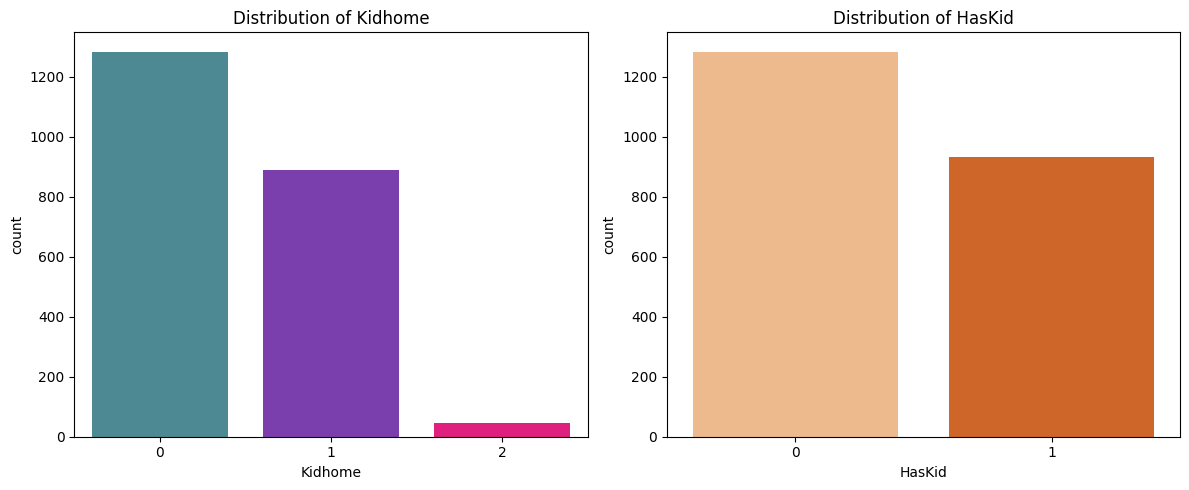

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.countplot(data=df, x='Kidhome', hue='Kidhome', ax=axes[0], palette=['#41929d', '#7B2CBF', '#FF007F'], legend=False)
axes[0].set_title('Distribution of Kidhome')


sns.countplot(data=df, x='HasKid', hue='HasKid', ax=axes[1], palette='Oranges', legend=False)
axes[1].set_title('Distribution of HasKid')

plt.tight_layout()
plt.show()